# Neural IVP tutorial

A neural IVP solves an initial value problem with no training data: we model the solution as a neural network $\mathbf{y}_{\pmb\theta}(\mathbf{t})$, where $\theta$ are the weights and biases of the network, and $\mathbf{y}, \mathbf{t} \in\mathbb{R}^{N_T}$, with $N_T$ the number of time steps. We enforce only:

1. the differential equation itself, through the ODE residual $dy/dt - f(y)$,
2. the initial condition $y(0) = y_0$.

The time derivative is computed exactly with automatic differentiation, so there is no stepping scheme and no numerical integration. This notebook implements the whole method from scratch using nothing but `torch`, `numpy`, and `matplotlib`.

We solve the simple first-order ODE
$$ \frac{dy}{dt} = \cos t, \qquad y(0) = 0, $$
which has the closed-form solution
$$ y(t) = \sin t. $$

We will train a small network to solve the IVP on $t \in [0, 2\pi]$.

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from IPython.display import display
from tqdm import tqdm

matplotlib.rcParams["font.family"] = "Times New Roman"
matplotlib.rcParams["font.size"] = 11
matplotlib.rcParams["mathtext.fontset"] = "stix"
matplotlib.rcParams["axes.linewidth"] = 0.8
matplotlib.rcParams["xtick.major.width"] = 0.8
matplotlib.rcParams["ytick.major.width"] = 0.8

DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print(f"Using device: {DEVICE}")

Using device: mps


In [2]:
def f(t):
    """Right-hand side of dy/dt = f(t)."""
    return torch.cos(t)


def analytic_solution(t):
    """Closed-form solution y(t) = sin(t), used only for comparison."""
    return torch.sin(t)


params = {
    "y0": 0.0,
    "T_MIN": 0.0,
    "T_MAX": 2.0 * torch.pi,
    "TIMESTEP": 0.05,
    "hidden": 64,
    "activation": "tanh",
    "epochs": 2000,
    "lr": 3e-3,
    "ODE_REGULARISER": 1.0,
    "IC_REGULARISER": 1.0,
}

dt = params["TIMESTEP"]
steps = int(round((params["T_MAX"] - params["T_MIN"]) / dt)) + 1
time_grid = torch.linspace(
    params["T_MIN"], params["T_MAX"], steps, dtype=torch.float, device=DEVICE
)
t = time_grid.unsqueeze(0).unsqueeze(2).requires_grad_(True)  # shape (1, T, 1)
y0 = params["y0"]

reference = analytic_solution(time_grid)
print(f"{steps} time points on t in [{params['T_MIN']}, {params['T_MAX']}], y(0) = {y0}")

127 time points on t in [0.0, 6.283185307179586], y(0) = 0.0


## The mechanics

**Ansatz.** A small MLP $\mathbf{y}_\theta(\mathbf{t})$ maps a vector of time to the predicted state. Evaluating it on the whole time grid in one batch gives the entire trajectory $\mathbf{y}(\mathbf{t})$ in a single forward pass.

**Derivative.** The output is differentiated with respect to the input time using `torch.autograd.grad`. Keeping `create_graph=True` means the derivative itself remains differentiable, which is what lets gradients flow from the residual back into the network weights.

**Loss.** The total loss combines the ODE residual with the initial condition:
$$ \mathcal{L} = \lambda_\mathrm{ODE} \, \mathrm{MSE}\!\left(\frac{\mathrm{d}\mathbf{y}_\theta(\mathbf{t})}{\mathrm{d}\mathbf{t}} - \mathbf{f}(\mathbf{y}(\mathbf{t}))\right) + \lambda_\mathrm{IC} \, \mathrm{MSE}\!\left(\mathbf{y}_\theta(0) - y_0\right)$$
There is no data term: the equation and the initial condition pin the solution down on their own.

In [3]:
def gradient(y, x):
    """First derivative dy/dx via automatic differentiation."""
    weights = torch.ones_like(y)
    return torch.autograd.grad(
        outputs=y,
        inputs=x,
        grad_outputs=weights,
        retain_graph=True,
        create_graph=True,
    )[0]


def sechlu(x):
    """Sech-LU activation: sigmoid-gated linear."""
    return torch.sigmoid(2.0 * x) * x


class MLP(nn.Module):
    """3 hidden layer MLP."""

    def __init__(self, in_features, hidden, out_features, activation):
        super().__init__()
        self.L1 = nn.Linear(in_features, hidden)
        self.L2 = nn.Linear(hidden, hidden)
        self.L3 = nn.Linear(hidden, hidden)
        self.L4 = nn.Linear(hidden, out_features)
        self.activation = activation

    def _act(self, x):
        if self.activation == "tanh":
            return torch.tanh(x)
        if self.activation == "relu":
            return torch.relu(x)
        return sechlu(x)

    def forward(self, x):
        x = self._act(self.L1(x))
        x = self._act(self.L2(x))
        x = self._act(self.L3(x))
        return self.L4(x)


model = MLP(
    in_features=1,
    hidden=params["hidden"],
    out_features=1,
    activation=params["activation"],
).to(DEVICE)

optimiser = torch.optim.Adam(model.parameters(), lr=params["lr"])
loss_fn = torch.nn.MSELoss()

In [4]:
def evaluate():
    prediction = model(t)
    dydt = gradient(prediction, t)

    ode_residual = dydt - f(t)
    ode_loss = loss_fn(ode_residual, torch.zeros_like(ode_residual))

    ic_target = torch.tensor([[y0]], dtype=torch.float, device=DEVICE)
    ic_loss = loss_fn(prediction[:, 0, :], ic_target)

    total_loss = (
        params["ODE_REGULARISER"] * ode_loss
        + params["IC_REGULARISER"] * ic_loss
    )
    return prediction, total_loss

In [5]:
def make_axes():
    fig = plt.figure(figsize=(6, 4), dpi=150)
    fig.patch.set_facecolor("white")
    ax = fig.add_subplot(111)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="in", which="both", left=True, bottom=True)
    ax.tick_params(labelbottom=True, labelleft=True)
    return fig, ax


def plot_trajectory(time_values, predicted, reference):
    fig, ax = make_axes()
    ax.plot(time_values, predicted, color="black", linewidth=2, label="Neural IVP")
    ax.plot(
        time_values,
        reference,
        color="lightgrey",
        linewidth=2.5,
        label="Analytic",
        zorder=-1,
    )
    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"$y(t)$")
    ax.legend(loc="upper right", frameon=False)
    return fig


def plot_loss_history(loss_history):
    fig, ax = make_axes()
    ax.semilogy(loss_history, linewidth=2, color="black")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    return fig

  0%|                                                 | 0/2000 [00:00<?, ?it/s]

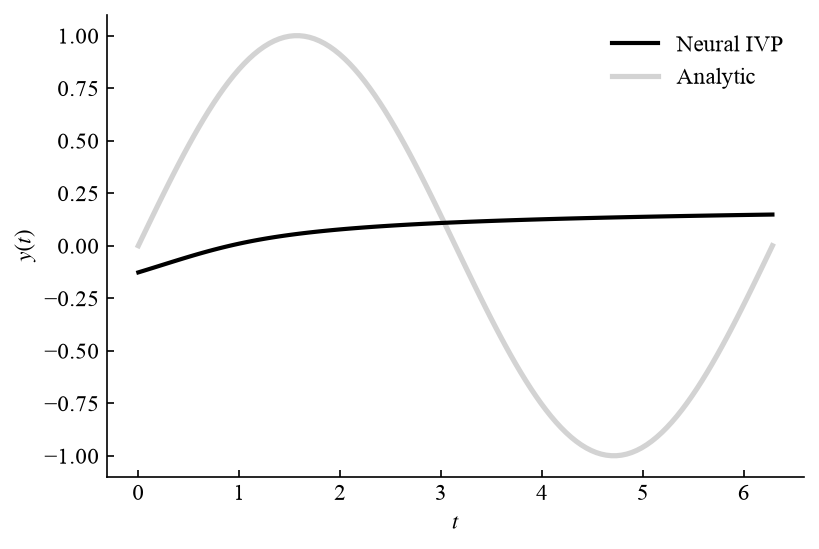

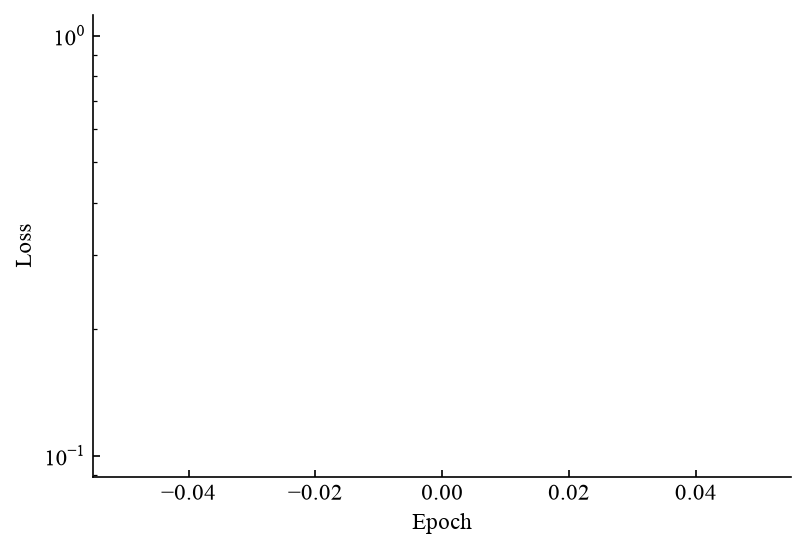

 24%|█████████▏                            | 486/2000 [00:01<00:03, 474.71it/s]

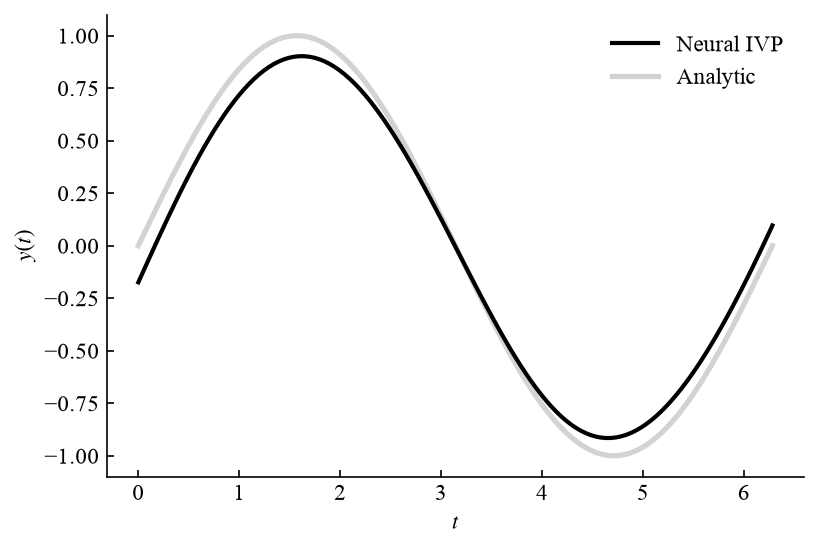

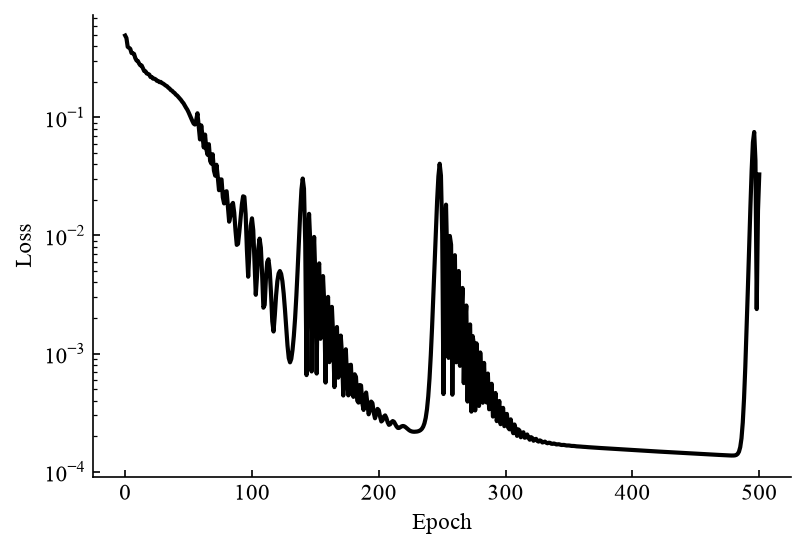

 48%|██████████████████▎                   | 966/2000 [00:02<00:02, 480.00it/s]

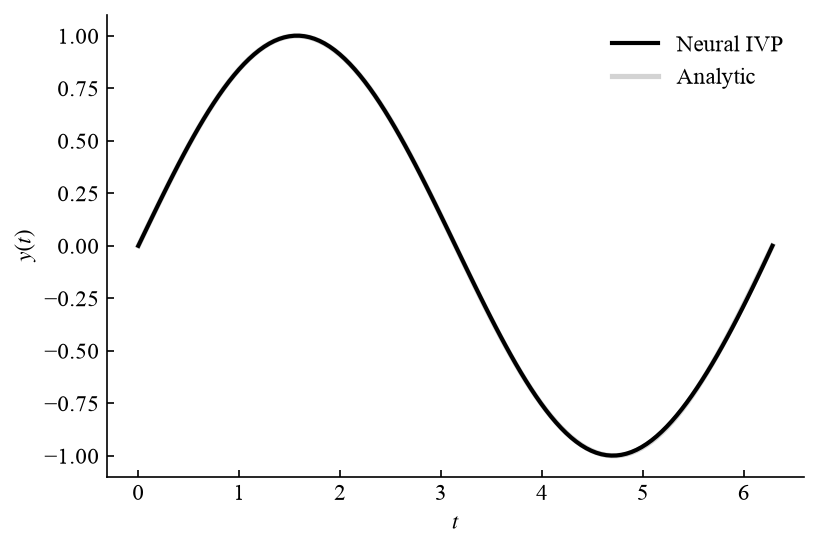

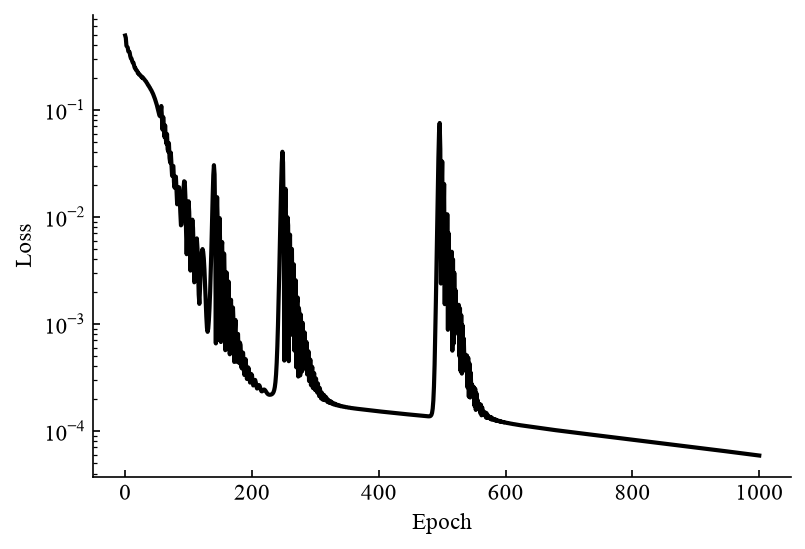

 74%|███████████████████████████▎         | 1479/2000 [00:03<00:01, 437.35it/s]

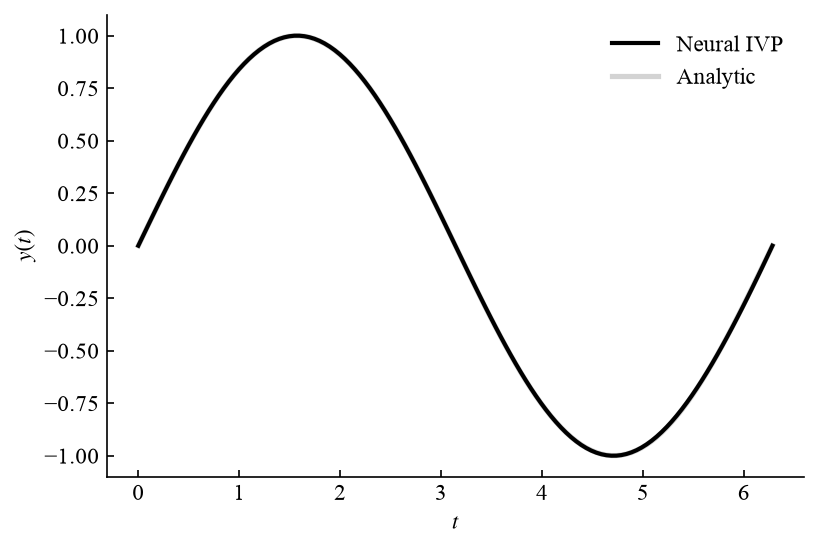

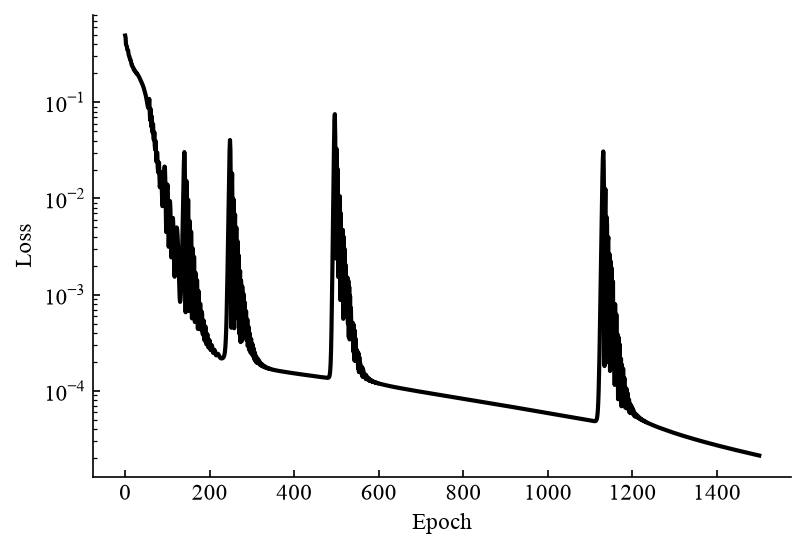

 99%|████████████████████████████████████▋| 1985/2000 [00:05<00:00, 300.45it/s]

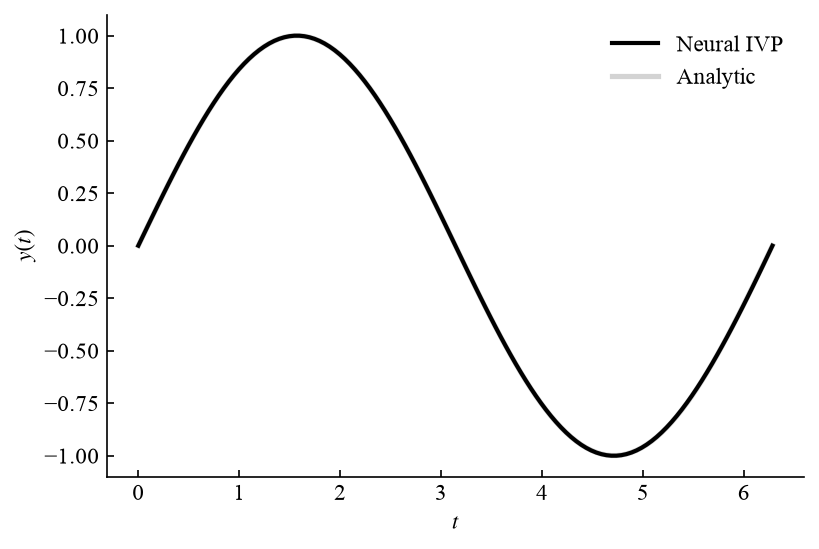

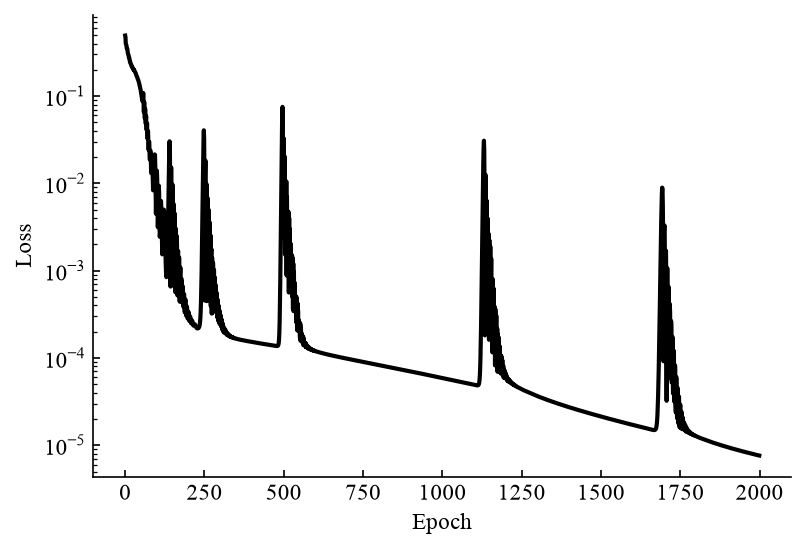

100%|█████████████████████████████████████| 2000/2000 [00:05<00:00, 384.00it/s]


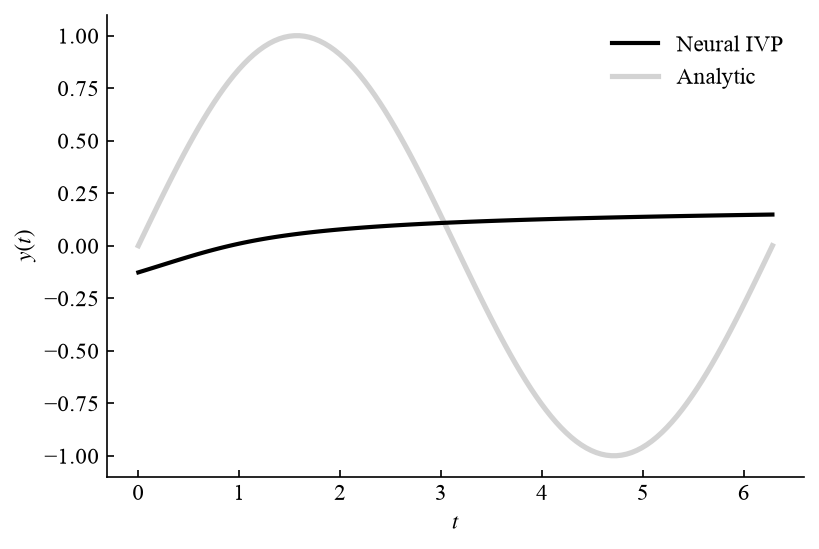

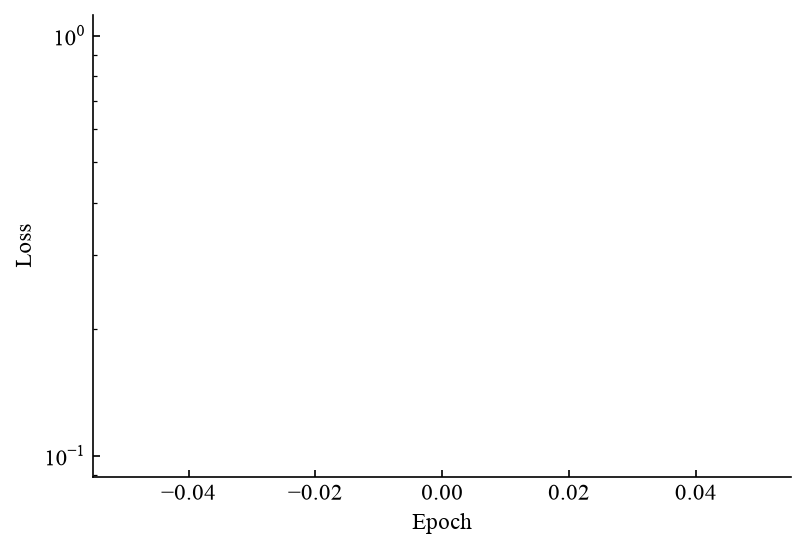

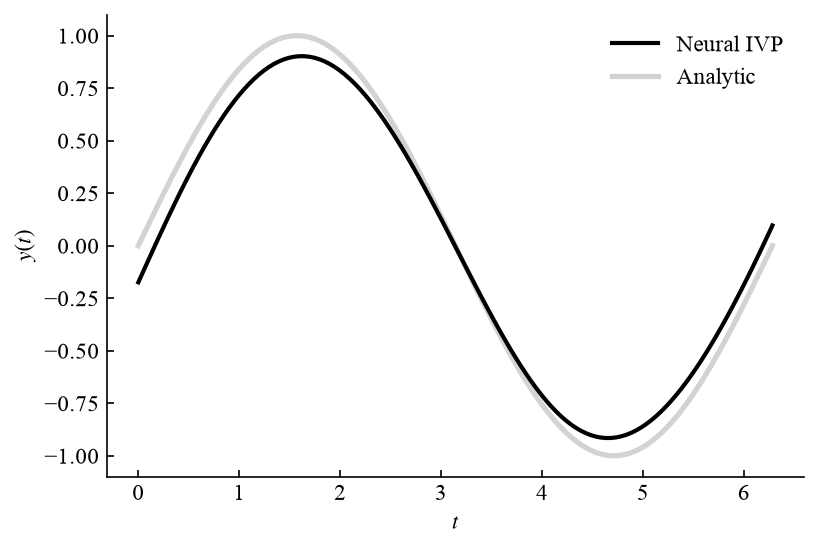

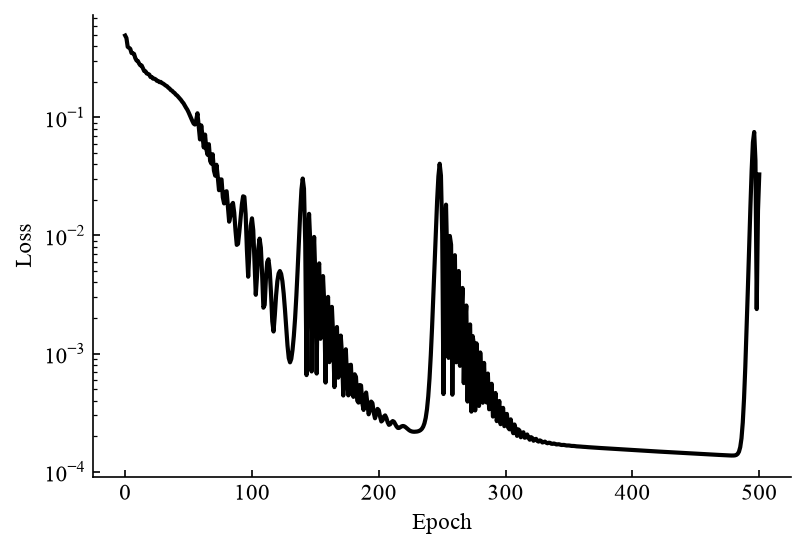

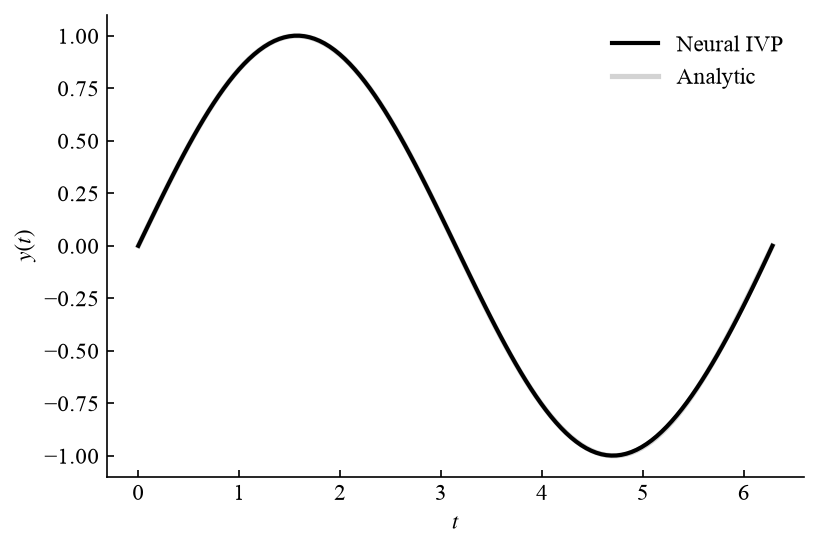

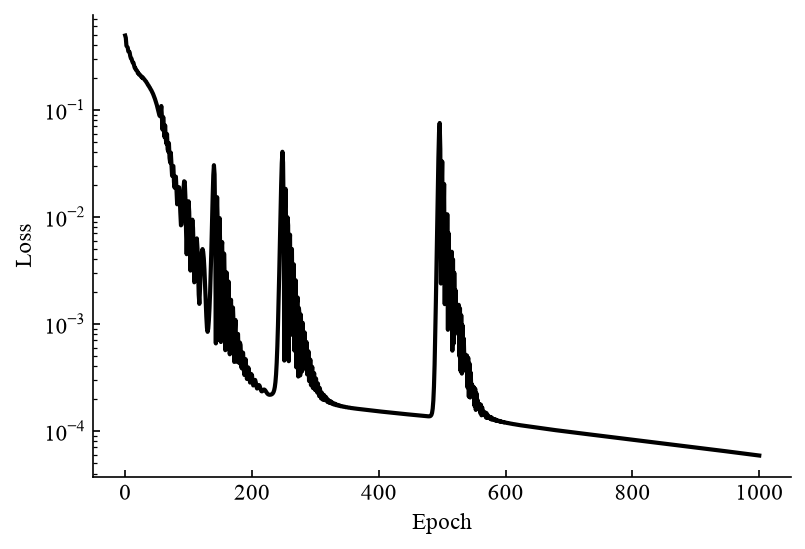

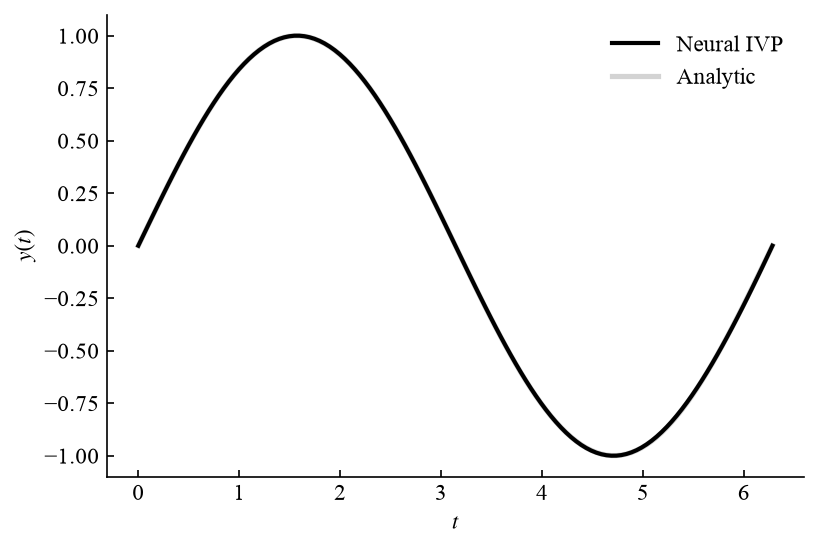

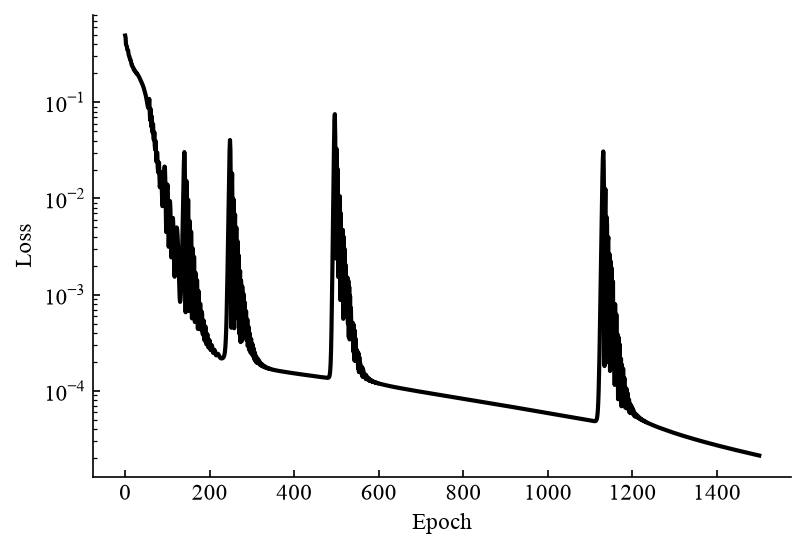

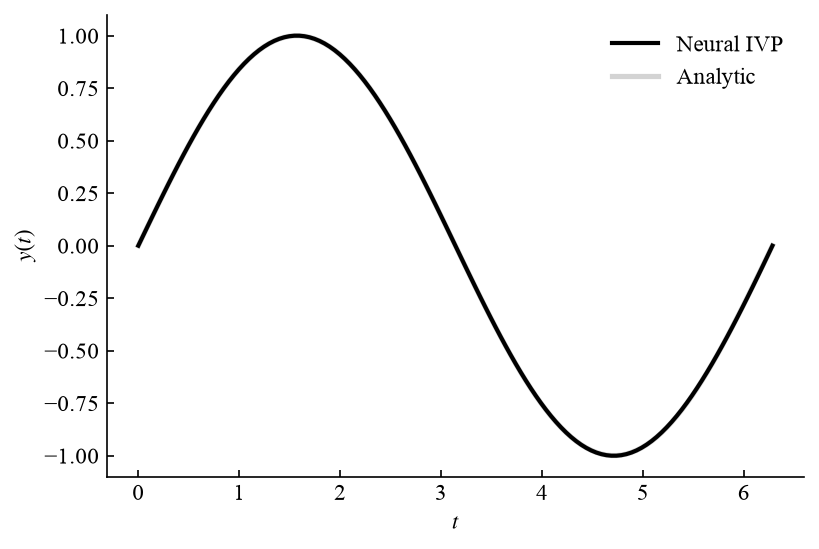

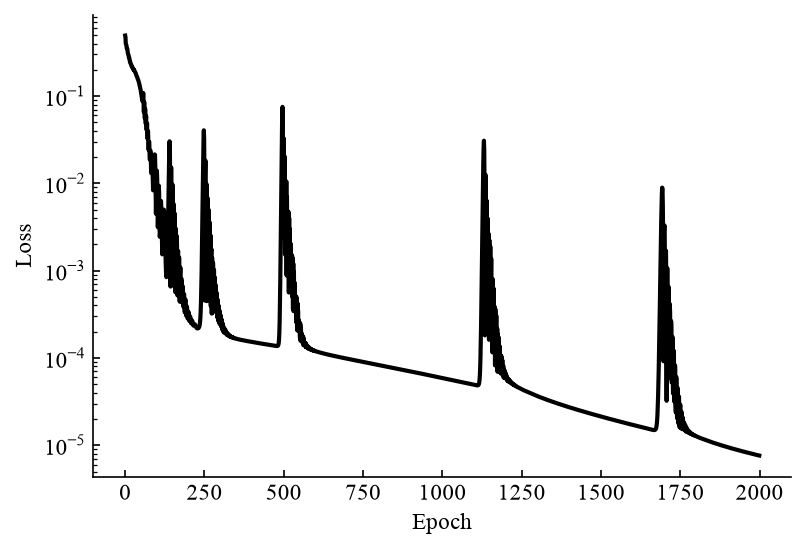

In [6]:
loss_history = []

for epoch in tqdm(range(params["epochs"])):
    prediction, total_loss = evaluate()
    optimiser.zero_grad()
    total_loss.backward()
    optimiser.step()
    loss_history.append(total_loss.item())

    if epoch % 500 == 0 or epoch == params["epochs"] - 1:
        time_values = time_grid.cpu().numpy()
        predicted_values = prediction[0, :, 0].detach().cpu().numpy()
        reference_values = reference.cpu().numpy()
        display(plot_trajectory(time_values, predicted_values, reference_values))
        display(plot_loss_history(loss_history))

Max |neural - analytic| over the interval: 1.663e-03
Saved trajectory.png and loss_history.png


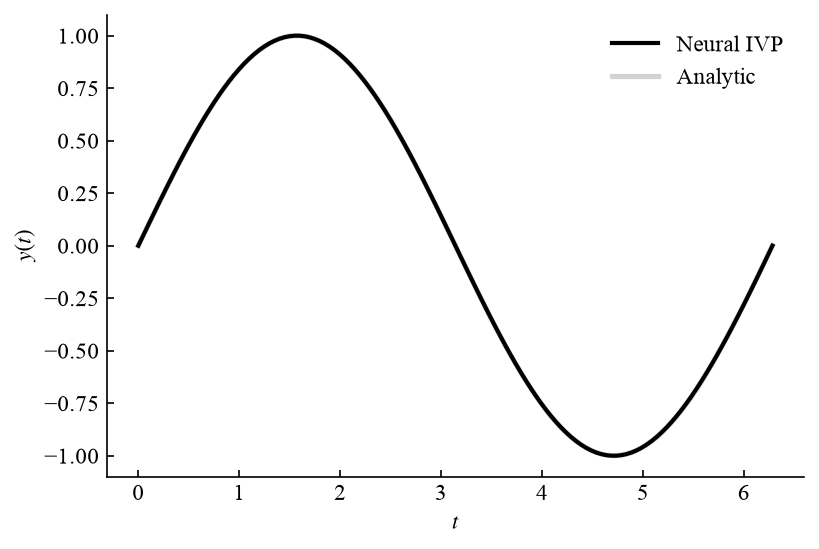

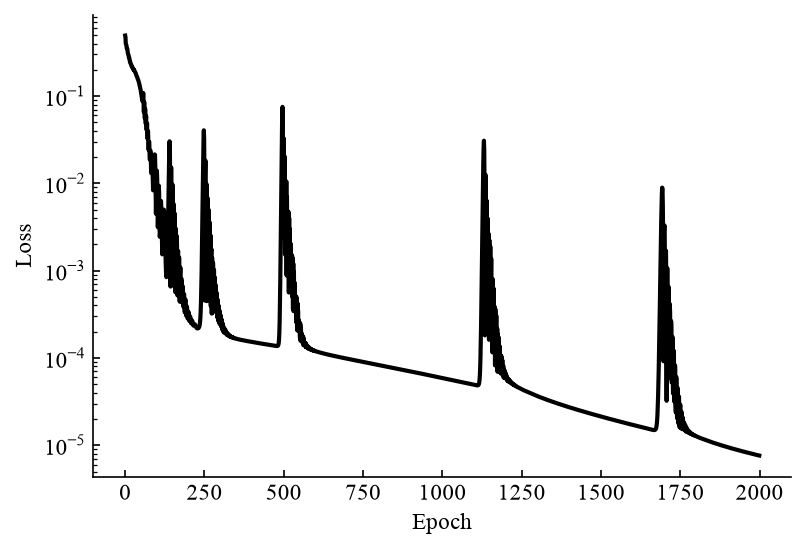

In [7]:
final_prediction, _ = evaluate()

time_values = time_grid.cpu().numpy()
predicted_values = final_prediction[0, :, 0].detach().cpu().numpy()
reference_values = reference.cpu().numpy()

max_error = float(np.max(np.abs(predicted_values - reference_values)))
print(f"Max |neural - analytic| over the interval: {max_error:.3e}")

plot_trajectory(time_values, predicted_values, reference_values).savefig(
    "trajectory.png", dpi=150, bbox_inches="tight"
)
plot_loss_history(loss_history).savefig(
    "loss_history.png", dpi=150, bbox_inches="tight"
)
print("Saved trajectory.png and loss_history.png")